# <ins>**MODELE KNN**</ins>

**Ce modèle d'apprentissage supervisé traite le problème de détection d'anomalies comme un problème de classification binaire sur données déséquilibrées (les anomalies représentent en général moins d'1% des observations).**

**Pour rappel, l'algorithme KNN est un discriminant d'apprentissage supervisé non paramétrique, qui utilise la proximité pour effectuer des classifications ou des prédictions sur le regroupement d'un point de données individuel. Bien qu'il puisse être utilisé pour des problèmes de régression ou de classification, il est généralement utilisé comme algorithme de classification, en partant de l'hypothèse que des points similaires peuvent être trouvés les uns à côté des autres. Le but de l'algorithme KNN est d'identifier les voisins les plus proches d'un point de requête donné afin d'attribuer un libellé de classe à ce point. Pour ce faire, l'algorithme a quelques exigences notamment la détermination des mesures de distance. Enfin pour déterminer quels points sont les plus proches d'un point de requête donné, il faut calculer la distance entre le point de requête et les autres points. Ces mesures de distance aident à former des limites de décision, qui partitionnent les points de requête en différentes régions.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import  SelectKBest
import logging
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2


### **1. Lecture de notre datasets**

In [52]:
# Chemin des fichiers
data_dir = Path("../data/raw/bronze/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

df = pd.read_csv(data_dir)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [53]:
# Décompte des différents labels
attack_counts = df[' Label'].value_counts(normalize=True)
print(attack_counts)

 Label
DDoS      0.567131
BENIGN    0.432869
Name: proportion, dtype: float64


### **2. Nettoyage du dataset**

In [54]:
def clean_column_network_data(df):
    """
    Nettoie les données réseau brutes du CICIDS2017

    Args:
        pd.DataFrame brute

    Returns:
        pd.DataFrame: DataFrame nettoyé et prêt pour l'analyse
    """
    # Configuration du logging
    logging.basicConfig(level=logging.INFO)

    try:
        # Nettoyage des noms de colonnes
        def clean_column_names(df):
            df.columns = (df.columns.str.strip()
                            .str.lower()
                            .str.replace('[^a-z0-9_]', '_', regex=True))
            return df
        df = clean_column_names(df)

        # Mapping des labels
        condition1 = df['label']=='BENIGN'
        condition2 = df['label']!='BENIGN'

        df.loc[condition1, 'label'] = 0
        df.loc[condition2, 'label'] = 1

        # Suppression des outliers astronomiques
        df = df.astype(float)
        df = df[np.isfinite(df).all(axis=1)]
        max_float32 = np.finfo(np.float32).max
        df = df[np.abs(df)<max_float32]

        # Suppression des lignes avec NaN après encodage et doublons
        initial_shape = df.shape[0]
        df = df.dropna(axis=0, how='any')
        # Suppression des doublons réseau critiques
        df = df.drop_duplicates()
        final_shape = df.shape[0]

        logging.info(f"Données nettoyées : {final_shape} lignes restantes ({initial_shape - final_shape} lignes supprimées)")

        return df

    except Exception as e:
        logging.error(f"Erreur lors du nettoyage : {str(e)}")
        raise

df = clean_column_network_data(df)

INFO:root:Données nettoyées : 223082 lignes restantes (2629 lignes supprimées)


In [55]:
df.head()

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,54865.0,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,55054.0,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,55055.0,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,46236.0,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,54863.0,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
# séparation des variables
y = df['label']
y = y.astype('int')
X = df.drop('label', axis = 1)

### **4. Normalisation de X et séparation en jeu d'entrainement et de test**

In [57]:
minmax = MinMaxScaler()
X = minmax.fit_transform(X)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

**Le dataframe comporte 79 variables dont 78 features. Pour des raisons d'efficacité, nous allons réduire le nombre de features afin de réduire la durée d'entrainement de notre modèle et d'avoir un modèle plus performant.**

**Pour ce faire, nous utilisons la fonction SelectKBest avec comme fonction de score la fonction de test du Chi2 qui permet de dire s'il y'a indépendance entre des variables. Cette fonction attribue des scores à chacune des variables du jeu de données et les features les plus importantes seront celles qui ont un score très élevé. Il est important de mentionner que le nombre de variables retourné par SelectKbest doit être précisé en argument lors de son appel.**

In [59]:
k_best_selector = SelectKBest(score_func=chi2, k=10)
X_train = k_best_selector.fit_transform(X_train, y_train)
X_test = k_best_selector.transform(X_test)

In [60]:
k_best_selector.get_feature_names_out()

array(['x0', 'x10', 'x12', 'x13', 'x25', 'x39', 'x40', 'x41', 'x48',
       'x54'], dtype=object)

### **5. Entrainement du modèle KNN sur le nouveau dataset constitué uniquement des variables retenues par SelectKBest.**

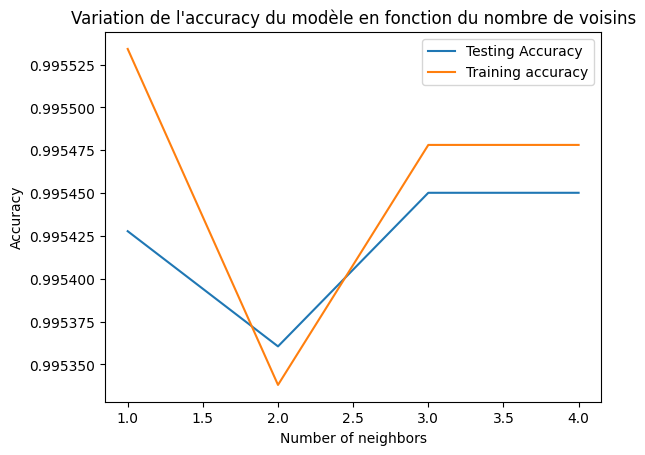

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

neighbours = np.arange(1,5)
train_accuracy =np.empty(len(neighbours))
test_accuracy = np.empty(len(neighbours))

for i,k in enumerate(neighbours):
    knn=KNeighborsClassifier(n_neighbors=k,algorithm="kd_tree",n_jobs=-1)
    knn.fit(X_train,y_train)
    train_accuracy[i] = knn.score(X_train, y_train)
    test_accuracy[i] = knn.score(X_test, y_test
)
plt.title("Variation de l'accuracy du modèle en fonction du nombre de voisins")
plt.plot(neighbours, test_accuracy, label='Testing Accuracy')
plt.plot(neighbours, train_accuracy, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()


In [62]:
idx = np.where(test_accuracy == max(test_accuracy)) #On cherche l'index d'accuracy maximale
x = neighbours[idx]
knn=KNeighborsClassifier(n_neighbors=x[0],algorithm="kd_tree",n_jobs=-1) #n_jobs=-1 signifie que l'on utilise tous les processeurs lors de la recherche de voisins means
knn.fit(X_train,y_train)

KNeighborsClassifier(algorithm='kd_tree', n_jobs=-1, n_neighbors=np.int64(3))

In [63]:
from sklearn.metrics import classification_report
knn_predicted_test_labels=knn.predict(X_test)
print(classification_report(y_test, knn_predicted_test_labels))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     18864
           1       0.99      1.00      1.00     25753

    accuracy                           1.00     44617
   macro avg       1.00      0.99      1.00     44617
weighted avg       1.00      1.00      1.00     44617



In [64]:
from sklearn.metrics import confusion_matrix, roc_auc_score, matthews_corrcoef, average_precision_score
print("Matrice de confusion:\n", confusion_matrix(y_test, knn_predicted_test_labels))
print("#"*50)
print("ROC-AUC SCORE:", roc_auc_score(y_test, knn_predicted_test_labels))
print("#"*50)
print("MCC Score:", matthews_corrcoef(y_test, knn_predicted_test_labels))
print("#"*50)
print("Precision-recall curve:", average_precision_score(y_test, knn_predicted_test_labels))

Matrice de confusion:
 [[18664   200]
 [    3 25750]]
##################################################
ROC-AUC SCORE: 0.9946406517293686
##################################################
MCC Score: 0.9907057060213805
##################################################
Precision-recall curve: 0.9922445163811686
